## 🛜 Drive & imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import os
import cv2
import numpy as np
import glob

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import requests
from io import BytesIO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.gridspec as gridspec


# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## 📸 Loading resized images and masks

In [ ]:
# @title Loading fun
import pandas as pd
import cv2
import os
import numpy as np
from tqdm import tqdm # Barra di caricamento opzionale ma comoda

def load_processed_data(dataset_dir='Dataset_Processato'):
    print(f"Inizio caricamento da: {dataset_dir}")

    # 1. Leggiamo il CSV con le etichette
    csv_path = os.path.join(dataset_dir, 'labels.csv')
    if not os.path.exists(csv_path):
        raise FileNotFoundError("Non trovo il file labels.csv!")

    df = pd.read_csv(csv_path)
    total_files = len(df)
    print(f"Trovate {total_files} immagini nel registro.")

    X = []
    y = []
    masks = []
    filenames = []

    # 2. Loop sulle righe del CSV
    # Uso tqdm per farti vedere la barra di progresso
    for index, row in tqdm(df.iterrows(), total=total_files):
        fname = row['filename']
        label = row['class_index']

        # Percorsi completi
        img_path = os.path.join(dataset_dir, 'images', fname)
        mask_path = os.path.join(dataset_dir, 'masks', fname)

        # --- CARICAMENTO IMMAGINE---
        # IMREAD_COLOR per caricare i 3 canali
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # OpenCV carica in BGR, convertiamo subito in RGB per coerenza
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- CARICAMENTO MASCHERA ---
        # Le maschere restano sempre in scala di grigi (IMREAD_GRAYSCALE)
        # perché non hanno colore, sono mappe di segmentazione.
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is not None and mask is not None:
            X.append(img)
            masks.append(mask)
            y.append(label)
            filenames.append(fname)
        else:
            print(f"Errore caricamento: {fname}")

    # 3. Conversione in array Numpy
    print("Conversione in array Numpy...")
    X = np.array(X)
    y = np.array(y)
    masks = np.array(masks)

    print(f"✅ Finito! Dataset caricato.")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")

    return X, y, masks, filenames


In [ ]:

# --- ESECUZIONE---
BASE_ROOT=Path('/content/drive/MyDrive/PROGETTO AI')
data=BASE_ROOT/'DATA RESIZED'

X_train_val, y_train_val, masks_train_val, loaded_filenames = load_processed_data(data)

# A questo punto hai i dati 0-255.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# @title Random Samples Visualization
import matplotlib.pyplot as plt
import numpy as np
import random

# Definizione mappa classi
class_map = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}

def visualize_random_samples(X, y, filenames, num_samples=9):
    """
    Visualizza campioni casuali mostrando anche il nome del file originale.
    """
    plt.figure(figsize=(15, 15))

    # Genera indici casuali
    # Assicuriamoci di non chiedere più campioni di quanti ne abbiamo
    num_samples = min(num_samples, len(X))
    indices = np.random.choice(len(X), num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i + 1)

        # Gestione visualizzazione (se float 0-1 o uint8 0-255)
        img = X[idx]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        plt.imshow(img)

        label_idx = y[idx]
        label_name = class_map.get(label_idx, "Unknown")

        # Recupera il nome del file corrispondente all'indice
        file_name = filenames[idx]

        # Titolo con tutte le info (uso \n per andare a capo)
        plt.title(f"Idx: {idx} | {file_name}\nClass: {label_name} ({label_idx})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_random_samples(X_train_val, y_train_val, loaded_filenames)

## ⚙️ Preprocessing - CLAHE

In [ ]:
# @title CLAHE fun
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_grayscale_and_clahe(X):
    """
    1. Converte immagini RGB in Grayscale.
    2. Applica CLAHE con parametri da paper (ClipLimit=4.0, Grid=8x8).

    Input: Array (N, H, W, 3) o (N, H, W)
    Output: Array (N, H, W, 1) pronto per la rete.
    """
    print(f"Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...")

    # Inizializza l'oggetto CLAHE con i parametri richiesti
    # clipLimit=4.0 rende il contrasto molto forte (utile per bordi tumorali)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))

    X_processed = []

    for i in range(len(X)):
        img = X[i]

        # --- CHECK VALIDITÀ (UINT8) ---
        # OpenCV CLAHE lavora su uint8 (0-255). Se i dati sono float 0-1, convertiamo.
        if img.dtype == 'float32' or img.dtype == 'float64':
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        # --- 1. CONVERSIONE GRAYSCALE ---
        # Se l'immagine ha 3 canali, la convertiamo. Se ne ha già 1 o 0 (flat), saltiamo.
        if len(img.shape) == 3 and img.shape[2] == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            # Se è già in scala di grigi (es. 256, 256) o (256, 256, 1)
            gray = img
            if len(gray.shape) == 3: # Rimuovi dimensione canale inutile se c'è
                gray = gray[:, :, 0]

        # --- 2. APPLICAZIONE CLAHE ---
        img_clahe = clahe.apply(gray)

        X_processed.append(img_clahe)

    # Conversione in array Numpy
    X_processed = np.array(X_processed)

    # --- RESHAPE FINALE ---
    # Le reti (come U-Net o ResNet) si aspettano un canale esplicito: (N, 256, 256, 1)
    # Attualmente X_processed è (N, 256, 256)
    X_final = np.expand_dims(X_processed, axis=-1)

    print(f"Processamento completato.")
    print(f"   Shape finale: {X_final.shape}")

    return X_final

Applicazione Grayscale + CLAHE (Clip: 4.0, Grid: 8x8)...
Processamento completato.
   Shape finale: (1503, 256, 256, 1)


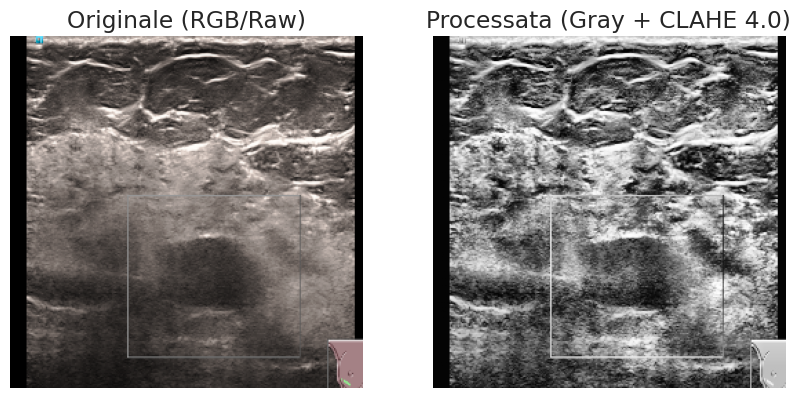

In [ ]:

# --- ESECUZIONE ---
X_train_val_clahe = apply_grayscale_and_clahe(X_train_val)

# --- VISUALIZZAZIONE CONTROLLO (Prima vs Dopo) ---
# È importante vedere l'effetto del ClipLimit=4, che è aggressivo.
idx = np.random.randint(0, len(X_train_val))

plt.figure(figsize=(10, 5))

# Immagine Originale (prendiamo la prima che capita o quella a colori)
plt.subplot(1, 2, 1)
if X_train_val[idx].shape[-1] == 3:
    plt.imshow(X_train_val[idx])
else:
    plt.imshow(X_train_val[idx].squeeze(), cmap='gray')
plt.title("Originale (RGB/Raw)")
plt.axis('off')

# Immagine Processata (CLAHE 4.0)
plt.subplot(1, 2, 2)
plt.imshow(X_train_val_clahe[idx].squeeze(), cmap='gray')
plt.title("Processata (Gray + CLAHE 4.0)")
plt.axis('off')

plt.show()

Ho seguito i valori usati nel paper dove si usa CLAHE che ho preso di riferimento (https://www.sciencedirect.com/science/article/pii/S2666521225000250).

Perchè funziona?
- Nell'immagine originale bordo del tumore (la massa scura centrale) è sfumato. C'è una transizione graduale tra il tessuto e la lesione. Per una CNN è più difficile capire dove finisce esattamente il tumore.

- Nell'immagine processata il bordo è diventato netto. Guardando il lato destro della massa: ora c'è un confine chiaro. Le CNN (specialmente quelle convoluzionali) funzionano rilevando gradienti (cambiamenti di intensità); qui il gradiente è fortissimo, facilitando enormemente il lavoro della rete.

Inoltre la texture interna non è visibile nell'immagine originale (sembra una macchia nera circa uniforme), mentre in quella processata si iniziano a vedere texture (variazioni di grigio) -> In oncologia, la differenza tra benigno e maligno è spesso nella disomogeneità interna. Un tumore maligno è spesso eterogeneo (caotico dentro).

## 🚆 Train-val split

In [ ]:
# @title Normalization & split function
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def normalize_and_split_robust(X, y, masks, filenames, val_size=0.2, random_state=42):
    print("="*60)
    print("1. PREPARAZIONE DATI E METADATI")
    print("="*60)

    # --- 1. NORMALIZZAZIONE (Se non già fatta) ---
    #if X.max() > 1.0:
      #  print("Normalizzazione immagini [0-255] -> [0-1]...")
        #X = X.astype('float32') / 255.0

    #if masks.max() > 1.0:
      #  print("Normalizzazione maschere [0-255] -> [0-1]...")
       # masks = masks.astype('float32') / 255.0
       # masks = (masks > 0.5).astype('float32') # Binarizzazione sicura

    # --- 2. CREAZIONE DATAFRAME PER GESTIRE I PAZIENTI ---
    df = pd.DataFrame({
        'filename': filenames,
        'label_orig': y,      # La label vera di ogni singola immagine
        'idx': range(len(y))  # Per recuperare l'immagine dall'array X dopo
    })

    # Estrazione ID Paziente
    # Si assume formato: "ID_imgNum.png" (es. 100_1.png -> ID 100)
    df['patient_id'] = df['filename'].apply(lambda x: x.split('_')[0])

    print(f"Totale Immagini: {len(df)}")
    print(f"Totale Pazienti: {df['patient_id'].nunique()}")

    # --- 3. DEFINIZIONE STRATEGIA DI STRATIFICAZIONE (PRIORITÀ) ---
    # Dobbiamo assegnare un'etichetta univoca a ogni PAZIENTE per lo split.
    # Regola: Se un paziente ha immagini miste, vince la classe più grave.
    # LA MAPPATURA ERA: 0=Benigno, 1=Maligno, 2=Normale .
    # Se la tua mappa è diversa, adatta questa parte!

    # Esempio logica: Cerchiamo se il paziente ha almeno un'immagine Maligna
    # Sostituisci i valori numerici con quelli reali del tuo dataset!
    MALIGNANT_CLASS = 1  # Esempio
    BENIGN_CLASS = 0     # Esempio
    NORMAL_CLASS = 2     # Esempio

    def get_patient_priority_label(patient_labels):
        classes_present = set(patient_labels)
        if MALIGNANT_CLASS in classes_present:
            return MALIGNANT_CLASS # Priorità massima
        elif BENIGN_CLASS in classes_present:
            return BENIGN_CLASS    # Priorità media
        else:
            return list(classes_present)[0] # Fallback (es. solo Normal)

    # Raggruppa per paziente e calcola la label prioritaria
    patient_strat_labels = df.groupby('patient_id')['label_orig'].apply(get_patient_priority_label)
    unique_patients = patient_strat_labels.index.values
    stratify_values = patient_strat_labels.values

    print("\n" + "="*60)
    print("2. SPLIT PAZIENTI (Stratificato su classe prioritaria)")
    print("="*60)

    # --- 4. SPLIT SUI PAZIENTI ---
    patients_train, patients_val = train_test_split(
        unique_patients,
        test_size=val_size,
        random_state=random_state,
        stratify=stratify_values # Stratifica basandosi sulla "gravità" del paziente
    )

    # --- 5. RECUPERO IMMAGINI (MANTENENDO LABEL ORIGINALI) ---
    # Selezioniamo le righe del DF che appartengono ai pazienti scelti
    df_train = df[df['patient_id'].isin(patients_train)]
    df_val = df[df['patient_id'].isin(patients_val)]

    # Estraiamo gli indici originali per prendere i dati dagli array numpy
    train_idx = df_train['idx'].values
    val_idx = df_val['idx'].values

    # Costruzione array finali
    X_train = X[train_idx]
    y_train = y[train_idx] # <-- QUI preserviamo la label originale dell'immagine!
    masks_train = masks[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]     # <-- Label originale
    masks_val = masks[val_idx]

    # --- 6. CHECK FINALE DISTRIBUZIONE ---
    print(f"\nSplit Completato.")
    print(f"Train set: {X_train.shape[0]} immagini ({len(patients_train)} pazienti)")
    print(f"Val set:   {X_val.shape[0]} immagini ({len(patients_val)} pazienti)")

    filenames_train = df_train['filename'].values  # <--- Aggiungi questo
    filenames_val = df_val['filename'].values      # <--- E questo

    def print_stats(y_arr, name):
        unique, counts = np.unique(y_arr, return_counts=True)
        print(f"\nDistribuzione Immagini {name}:")
        tot = len(y_arr)
        for u, c in zip(unique, counts):
            print(f"  Classe {u}: {c} ({c/tot*100:.1f}%)")

    print_stats(y_train, "TRAIN")
    print_stats(y_val, "VALIDATION")



    return X_train, y_train, masks_train, filenames_train, X_val, y_val, masks_val, filenames_val



In [ ]:

# --- ESECUZIONE ---
X_train, y_train, masks_train, filenames_train, X_val, y_val, masks_val, filenames_val = normalize_and_split_robust(
    X_train_val_clahe,
    y_train_val,
    masks_train_val,
    loaded_filenames,
    val_size=0.2
)

1. PREPARAZIONE DATI E METADATI
Totale Immagini: 1503
Totale Pazienti: 968

2. SPLIT PAZIENTI (Stratificato su classe prioritaria)

Split Completato.
Train set: 1227 immagini (774 pazienti)
Val set:   276 immagini (194 pazienti)

Distribuzione Immagini TRAIN:
  Classe 0: 554 (45.2%)
  Classe 1: 295 (24.0%)
  Classe 2: 378 (30.8%)

Distribuzione Immagini VALIDATION:
  Classe 0: 125 (45.3%)
  Classe 1: 69 (25.0%)
  Classe 2: 82 (29.7%)


I confirmed patiets are actually 968, not 1071 as it could have been assumed looking at the excel file (indeed user ids are not always subsequent and some numbers are missing, for example 121-133)

## 👩🏻‍💻 Data augmentation

In [ ]:
import pandas as pd
import numpy as np
import albumentations as A
import cv2
'''
Per essere sicuri di fare augmentation sull'immagine e sulla relativa maschera
corretta, carico il file excel training_metadata
'''
# 1. Carichiamo il "Registro Ufficiale" (il tuo CSV)
# Assicurati che il percorso del file sia corretto
df_meta = pd.read_excel(BASE_ROOT/'Assignment_25_26/training_metadata.xlsx')

# Creiamo un dizionario di verifica: { 'nome_immagine': 'nome_maschera' }
# Es: {'1.png': '1_mask.png', ...}
integrity_map = dict(zip(df_meta['US'], df_meta['MASK']))

print(f"Registro di integrità caricato: {len(integrity_map)} coppie verificate.")

Registro di integrità caricato: 1503 coppie verificate.


In [ ]:
# @title Offline augmentation - Class imbalance
import albumentations as A
import cv2
import numpy as np

def balance_dataset_offline(X_train, y_train, masks_train, filenames_train, integrity_map):
    print("="*80)
    print("BILANCIAMENTO DATASET OFFLINE (Con Verifica Filename)")
    print("="*80)

    # --- FIX 1: Copia profonda per non modificare gli originali per errore ---
    X_work = X_train.copy()
    masks_work = masks_train.copy()
    filenames_arr = np.array(filenames_train)

    # --- FIX 2: Conversione GLOBALE preventiva in uint8 ---
    # Convertiamo tutto subito, così siamo sicuri al 100% che Albumentations riceva interi
    if X_work.dtype != np.uint8:
        print("Conversione X_train in uint8...")
        if X_work.max() <= 1.5: # È float 0-1
            X_work = (X_work * 255).astype(np.uint8)
        else: # È float 0-255 o altro
            X_work = X_work.astype(np.uint8)

    if masks_work.dtype != np.uint8:
        print("Conversione masks_train in uint8...")
        masks_work = (masks_work > 0.5).astype(np.uint8) # Binarizzazione sicura

    unique, counts = np.unique(y_train, return_counts=True)
    max_count = np.max(counts)

    print(f"Distribuzione Iniziale: {dict(zip(unique, counts))}")
    print(f"Target per classe: {max_count}")

    X_bal = []
    y_bal = []
    masks_bal = []
    filenames_bal = []

    # Pipeline Elastic Deformation (Parametri discussi e validati)
    elastic_transform = A.Compose([
        A.ElasticTransform(
            alpha=100, sigma=10, alpha_affine=10,
            border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=1.0
        )
    ])

    for class_id in unique:
        # Indici originali
        idxs = np.where(y_train == class_id)[0]

        # Prendi i dati dalla versione uint8 (X_work)
        X_class = X_work[idxs]
        masks_class = masks_work[idxs]
        y_class = y_train[idxs] # Le label rimangono le stesse
        fnames_class = filenames_arr[idxs]

        # Aggiungi originali
        X_bal.extend(X_class)
        masks_bal.extend(masks_class)
        y_bal.extend(y_class)
        filenames_bal.extend(fnames_class)

        current = len(X_class)
        needed = max_count - current

        if needed > 0:
            print(f"\n> Classe {class_id}: Generazione di {needed} copie sintetiche...")
            for i in range(needed):
                rand_i = np.random.randint(0, current)

                # Prendi l'immagine già convertita in uint8
                img_orig = X_class[rand_i]
                mask_orig = masks_class[rand_i]
                fname_orig = fnames_class[rand_i]

                # Check sicurezza
                expected_mask = integrity_map.get(fname_orig, "NOT_FOUND")
                if i < 1: print(f"  [Check] Deformazione: {fname_orig} -> Maschera attesa: {expected_mask}")

                # Applicazione (Ora siamo sicuri che riceve uint8)
                aug = elastic_transform(image=img_orig, mask=mask_orig)

                # --- FIX 3: Verifica che l'immagine sia cambiata ---
                # (Opzionale, solo per debug estremo)
                if np.array_equal(img_orig, aug['image']):
                    print(f"  WARNING: L'immagine {fname_orig} non è cambiata! Controlla i parametri.")

                X_bal.append(aug['image'])
                masks_bal.append(aug['mask'])
                y_bal.append(class_id)
                filenames_bal.append(f"{fname_orig}_aug_{i}")
        else:
            print(f"> Classe {class_id}: Già bilanciata.")

    print("="*80)
    print(f"Generazione completata. Dataset finale: {len(X_bal)}")

    return np.array(X_bal), np.array(y_bal), np.array(masks_bal), np.array(filenames_bal)

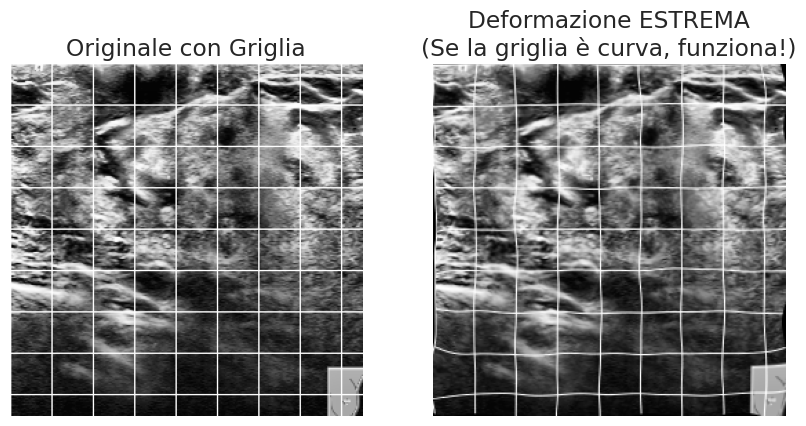

In [ ]:
# @title Check che deformazione avvenga
import numpy as np
import cv2
import albumentations as A
import matplotlib.pyplot as plt

def test_grid_deformation(image):
    # 1. Creiamo una copia e disegniamo una GRIGLIA sopra
    # Questo serve a rendere evidentissima la deformazione
    img_grid = image.copy()

    # Assicuriamoci sia uint8 e grayscale o RGB
    if img_grid.max() <= 1.0:
        img_grid = (img_grid * 255).astype(np.uint8)
    else:
        img_grid = img_grid.astype(np.uint8)

    # Se è grayscale (H, W) o (H, W, 1), convertiamo in BGR per disegnare linee colorate
    if img_grid.ndim == 2:
        img_grid = cv2.cvtColor(img_grid, cv2.COLOR_GRAY2BGR)
    elif img_grid.shape[2] == 1:
        img_grid = cv2.cvtColor(img_grid, cv2.COLOR_GRAY2BGR)

    step = 30 # Distanza righe griglia
    h, w = img_grid.shape[:2]

    # Disegna righe verticali e orizzontali (Bianche)
    for x in range(0, w, step):
        cv2.line(img_grid, (x, 0), (x, h), (255, 255, 255), 1)
    for y in range(0, h, step):
        cv2.line(img_grid, (0, y), (w, y), (255, 255, 255), 1)

    # 2. Definiamo una trasformazione "NUCLEAR" (Estrema)
    # alpha=300 su 256px significa spostare i pixel anche dall'altra parte dell'immagine!
    # sigma=15 mantiene la deformazione locale (tipo vortice)
    aug_extreme = A.Compose([
        A.ElasticTransform(
            alpha=100,
            sigma=10,
            alpha_affine=10,
            border_mode=cv2.BORDER_CONSTANT, value=0,
            p=1.0
        )
    ])

    # 3. Applichiamo
    res = aug_extreme(image=img_grid)
    img_deformed = res['image']

    # 4. Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_grid)
    plt.title("Originale con Griglia")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_deformed)
    plt.title("Deformazione ESTREMA\n(Se la griglia è curva, funziona!)")
    plt.axis('off')
    plt.show()

# --- ESEGUI IL TEST ---
# Prendi un'immagine a caso dal tuo X_train
test_idx = np.random.randint(0, len(X_train))
test_grid_deformation(X_train[test_idx])

Da qui confermo che i parametri impostati per la deformazione, deformino effettivamente l'immagine

In [ ]:
# --- ESECUZIONE ---
# Richiede X_train, y_train, masks_train ottenuti dallo split precedente
# E richiede 'filenames_train'


X_train_bal, y_train_bal, masks_train_bal, fnames_train_bal = balance_dataset_offline(
    X_train, y_train, masks_train,
    filenames_train, # <--- IMPORTANTE: Deve essere la lista dei nomi del training set
    integrity_map
)

BILANCIAMENTO DATASET OFFLINE (Con Verifica Filename)
Distribuzione Iniziale: {np.int64(0): np.int64(554), np.int64(1): np.int64(295), np.int64(2): np.int64(378)}
Target per classe: 554
> Classe 0: Già bilanciata.

> Classe 1: Generazione di 259 copie sintetiche...
  [Check] Deformazione: 1071_1.png -> Maschera attesa: 1071_1_mask.png

> Classe 2: Generazione di 176 copie sintetiche...
  [Check] Deformazione: 1058_11.png -> Maschera attesa: 1058_11_mask.png
Generazione completata. Dataset finale: 1662


Visualizzazione di 3 esempi di augmentation...


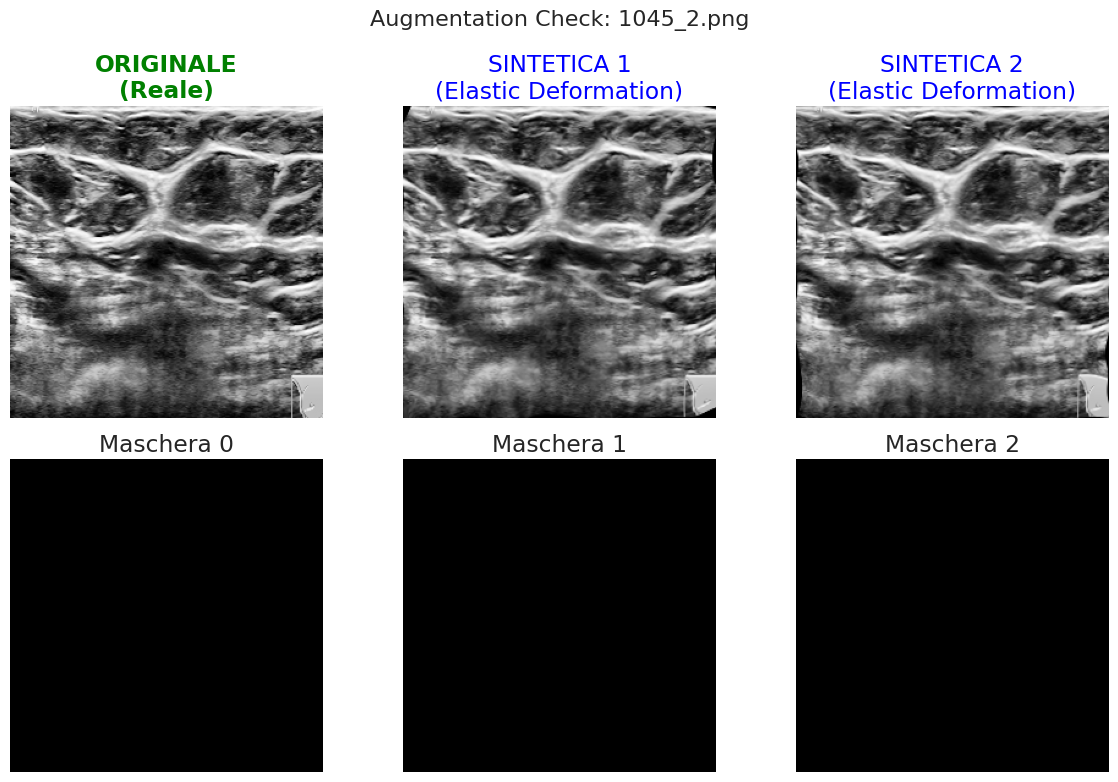

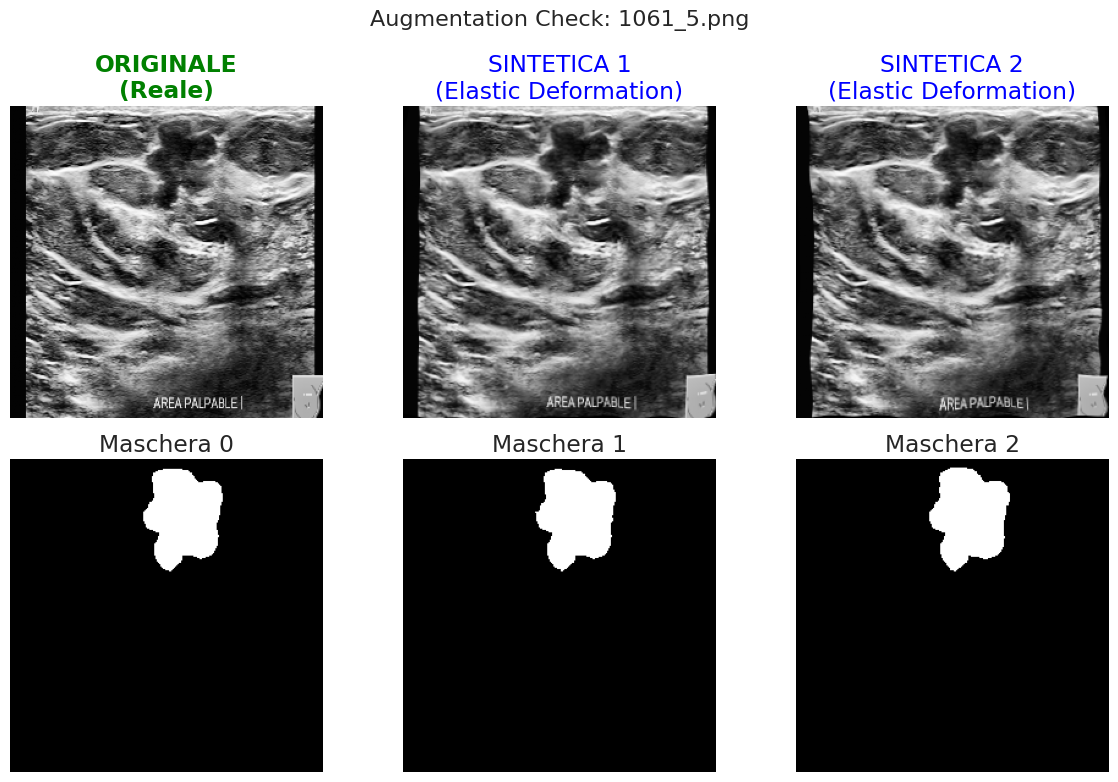

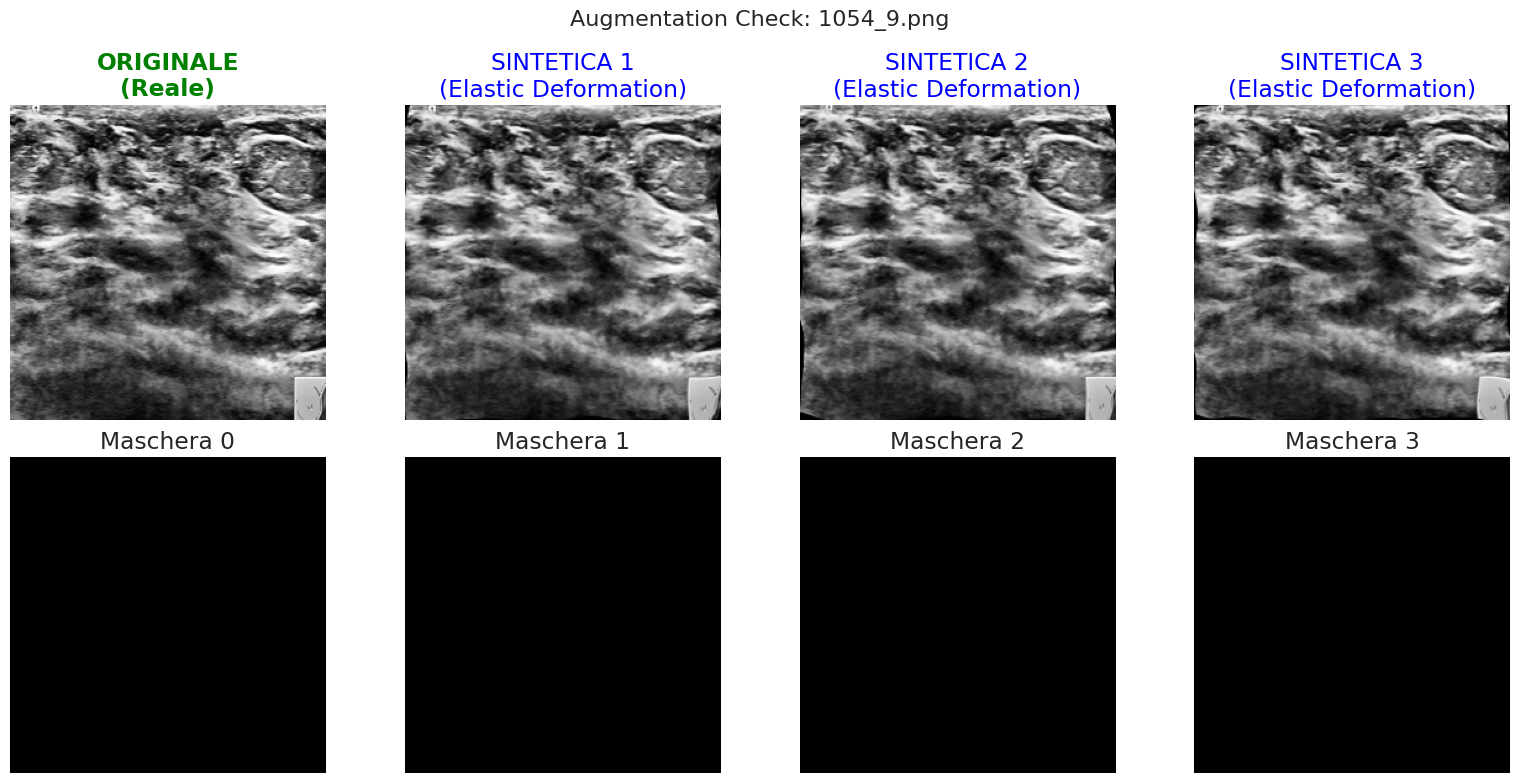

In [ ]:
# @title Visualization
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_augmentation_results(X, masks, filenames, num_examples=1):
    """
    Cerca immagini che hanno subito augmentation (hanno suffisso '_aug_')
    e visualizza l'originale accanto alle sue varianti sintetiche.
    """
    # 1. Troviamo i "nomi base" di tutte le immagini augmentate
    # I file augmentati hanno nomi tipo "100_1.png_aug_0"
    aug_indices = [i for i, f in enumerate(filenames) if "_aug_" in f]

    if len(aug_indices) == 0:
        print("Nessuna immagine augmentata trovata nel dataset fornito.")
        return

    # Estraiamo i nomi originali unici che hanno generato augmentation
    aug_filenames_set = set()
    for idx in aug_indices:
        # "100_1.png_aug_0" -> split -> "100_1.png"
        base_name = filenames[idx].split('_aug_')[0]
        aug_filenames_set.add(base_name)

    # 2. Selezioniamo n esempi a caso
    selected_bases = random.sample(list(aug_filenames_set), min(num_examples, len(aug_filenames_set)))

    print(f"Visualizzazione di {len(selected_bases)} esempi di augmentation...")

    for base_name in selected_bases:
        # Trova indice originale
        # Nota: potrebbe essere che filenames sia un array numpy, quindi usiamo np.where
        orig_indices = np.where(filenames == base_name)[0]

        # Trova indici augmentati
        # Cerchiamo stringhe che iniziano con "base_name + _aug_"
        # (Un po' macchinoso con numpy string arrays, facciamo list comp per sicurezza)
        aug_indices_family = [i for i, f in enumerate(filenames) if f.startswith(base_name + "_aug_")]

        if len(orig_indices) == 0:
            print(f"Attenzione: Originale per {base_name} non trovato (forse rimosso?). Mostro solo augmented.")
            continue

        orig_idx = orig_indices[0]

        # Raccogliamo tutti gli indici (Originale + Augmentati)
        all_indices = [orig_idx] + aug_indices_family

        # --- PLOT ---
        n_imgs = len(all_indices)
        # Creiamo una figura larga abbastanza
        fig, axes = plt.subplots(2, n_imgs, figsize=(4 * n_imgs, 8))

        # Titolo generale
        fig.suptitle(f"Augmentation Check: {base_name}", fontsize=16)

        for i, idx in enumerate(all_indices):
            # Immagine
            ax_img = axes[0, i] if n_imgs > 1 else axes[0]
            img_show = X[idx]

            # Se è (256, 256, 1) o (256, 256), rimuoviamo dim inutile per plot
            if img_show.ndim == 3 and img_show.shape[-1] == 1:
                img_show = img_show.squeeze()

            ax_img.imshow(img_show, cmap='gray')

            if i == 0:
                ax_img.set_title("ORIGINALE\n(Reale)", color='green', fontweight='bold')
            else:
                ax_img.set_title(f"SINTETICA {i}\n(Elastic Deformation)", color='blue')
            ax_img.axis('off')

            # Maschera
            ax_mask = axes[1, i] if n_imgs > 1 else axes[1]
            mask_show = masks[idx]
            if mask_show.ndim == 3: mask_show = mask_show.squeeze()

            ax_mask.imshow(mask_show, cmap='gray')
            ax_mask.set_title(f"Maschera {i}")
            ax_mask.axis('off')

        plt.tight_layout()
        plt.show()

# --- ESECUZIONE ---
# Assumiamo che le tue variabili si chiamino X_train_bal, masks_train_bal, filenames_bal
# (quelle uscite dalla funzione balance_dataset_offline_verified)
visualize_augmentation_results(X_train_bal, masks_train_bal, fnames_train_bal, num_examples=3)

A occhio nudo non sembra cambiare nulla nelle immagini

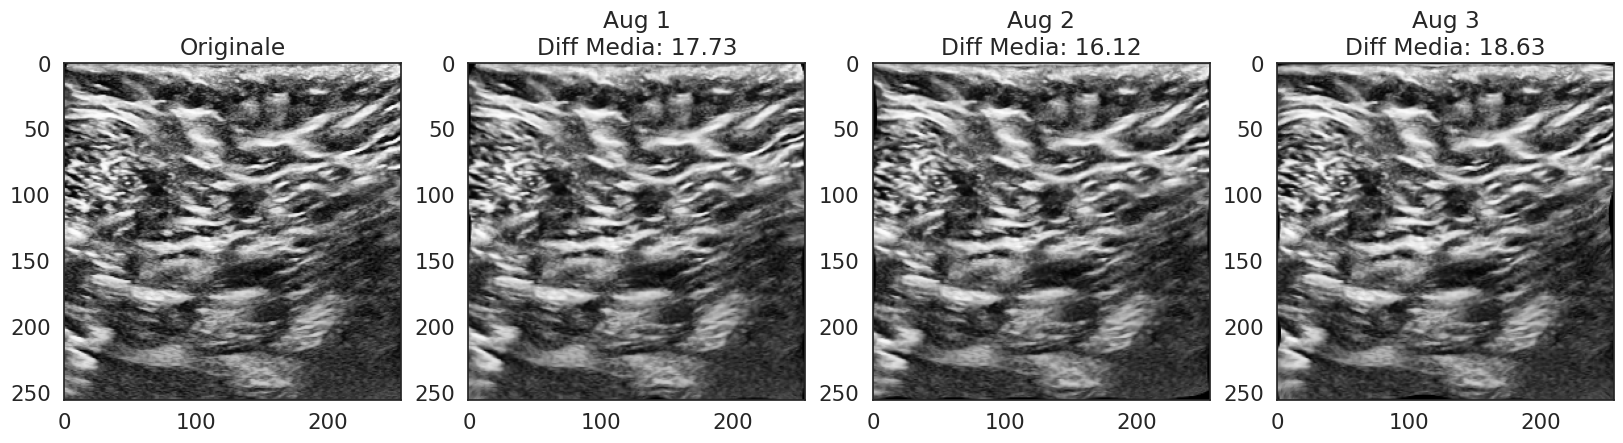

In [ ]:
# @title Check differenza media
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisci la trasformazione ESATTA che stai usando
elastic_transform = A.Compose([
    A.ElasticTransform(
        alpha=100, sigma=10, alpha_affine=10,
        border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=1.0
    )
])

# 2. Prendi un'immagine dal tuo train set (assicurandoti che sia uint8)
idx = 0
img_orig = X_train[idx].copy()

# Conversione manuale per sicurezza
if img_orig.max() <= 1.0:
    img_orig = (img_orig * 255).astype(np.uint8)
else:
    img_orig = img_orig.astype(np.uint8)

# 3. Applica la trasformazione 3 volte
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Originale
axes[0].imshow(img_orig.squeeze(), cmap='gray')
axes[0].set_title("Originale")

# 3 Varianti
for i in range(1, 4):
    res = elastic_transform(image=img_orig)
    aug_img = res['image']

    # Calcola la differenza numerica (pixel per pixel)
    diff = np.abs(img_orig.astype(float) - aug_img.astype(float))
    mean_diff = np.mean(diff)

    axes[i].imshow(aug_img.squeeze(), cmap='gray')
    axes[i].set_title(f"Aug {i}\nDiff Media: {mean_diff:.2f}")

plt.show()

Ma qui calcolo la differenza media pixel per pixel rispetto all'originale --> è ≠0 quindi OK sta funzionando

In [ ]:
# @title Online augmentation - transforms definition
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

# 1. TRAIN TRANSFORM (Online Augmentation)
# Include le geometriche richieste dal paper + normalizzazione finale
train_transform = A.Compose([
    # Le due richieste del paper:
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=5, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
])

# 2. VAL TRANSFORM (Solo formattazione)
# Nessuna modifica geometrica, il validation deve rimanere "fermo"
val_transform = A.Compose([
    # Qui non mettiamo nulla se le immagini sono già 256x256
])

In [ ]:
# @title Online augmentation - Loader fun
class BreastUSDataset(Dataset):
    def __init__(self, images, masks, labels, transform=None):
        """
        images: Array numpy (N, H, W) o (N, H, W, 1) in uint8 (0-255)
        masks:  Array numpy (N, H, W) o (N, H, W, 1) in uint8 (0, 1 o 0, 255)
        labels: Array o lista di etichette
        transform: Pipeline Albumentations
        """
        self.images = images
        self.masks = masks
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Recupera dati
        img = self.images[idx]
        mask = self.masks[idx]
        label = self.labels[idx]

        # Assicuriamoci che siano uint8 per Albumentations
        # (Dovrebbero già esserlo grazie allo step precedente, ma per sicurezza...)
        if img.dtype != 'uint8':
            if img.max() <= 1.5: img = (img * 255).astype('uint8')
            else: img = img.astype('uint8')

        # Gestione Maschera (assicuriamoci sia binaria 0-1 uint8 se possibile, o 0-255)
        # Per albumentations va bene qualsiasi, ma dopo normalizzeremo.

        # 2. Applica Augmentation (se definita)
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # 3. PREPARAZIONE PER PYTORCH (Cruciale)

        # A) Normalizzazione [0, 255] -> [0.0, 1.0] float32
        img = img.astype('float32') / 255.0
        mask = mask.astype('float32')

        # Se la maschera era 0-255, la portiamo a 0-1
        if mask.max() > 1.0:
            mask = mask / 255.0
        # Binarizzazione pulita (threshold a 0.5)
        mask = (mask > 0.5).astype('float32')

        # B) Gestione Dimensioni (H, W) -> (H, W, 1) se manca il canale
        if img.ndim == 2:
            img = img[:, :, None] # Aggiunge asse canale alla fine
        if mask.ndim == 2:
            mask = mask[:, :, None]

        # C) Permutazione Assi: (H, W, C) -> (C, H, W) richiesto da PyTorch
        # Numpy/OpenCV usano HWC, PyTorch usa CHW
        img = torch.from_numpy(img).permute(2, 0, 1)   # Diventa (1, 256, 256)
        mask = torch.from_numpy(mask).permute(2, 0, 1) # Diventa (1, 256, 256)

        # D) Label
        label = torch.tensor(label, dtype=torch.long)

        return img, mask, label

In [ ]:
# --- CONFIGURAZIONE BATCH SIZE ---
BATCH_SIZE = 32

# 1. Dataset di Training (Usa i dati BILANCIATI + Transform ONLINE)
train_dataset = BreastUSDataset(
    X_train_bal,
    masks_train_bal,
    y_train_bal,
    transform=train_transform
)

# 2. Dataset di Validation (Usa i dati ORIGINALI + Transform VUOTA)
# Il Validation NON deve essere bilanciato artificialmente, deve riflettere la realtà.
val_dataset = BreastUSDataset(
    X_val,
    masks_val,
    y_val,
    transform=val_transform
)

# 3. Creazione DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,       # IMPORTANTE: Mescolare i dati di training
    num_workers=2,      # Velocizza il caricamento (usa 0 se dà errori su Windows)
    pin_memory=True     # Velocizza trasferimento su GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # Non serve mescolare il validation
    num_workers=2,
    pin_memory=True
)

print(f"   DataLoaders pronti.")
print(f"   Batch Train: {len(train_loader)} (Totale img: {len(train_dataset)})")
print(f"   Batch Val:   {len(val_loader)} (Totale img: {len(val_dataset)})")

   DataLoaders pronti.
   Batch Train: 52 (Totale img: 1662)
   Batch Val:   9 (Totale img: 276)



--- CONTROLLO BATCH ---
Shape Immagini (Batch, C, H, W): torch.Size([32, 1, 256, 256])
Shape Maschere (Batch, C, H, W): torch.Size([32, 1, 256, 256])
Shape Label: torch.Size([32])
Range valori Immagine: Min 0.0000, Max 1.0000
Range valori Maschera: Unique tensor([0., 1.])


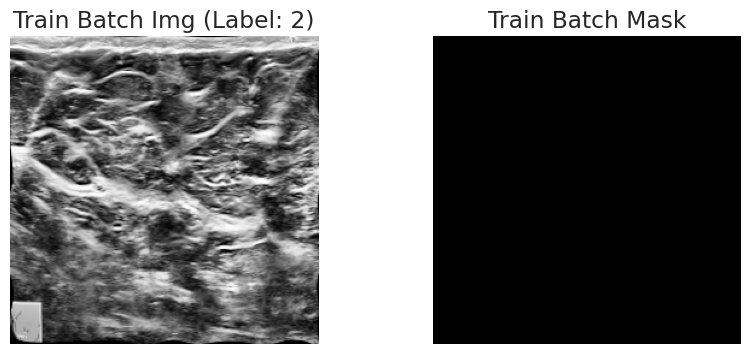

In [ ]:
# Estrai un batch per controllo
images, masks, labels = next(iter(train_loader))

print("\n--- CONTROLLO BATCH ---")
print(f"Shape Immagini (Batch, C, H, W): {images.shape}") # Dovrebbe essere (16, 1, 256, 256)
print(f"Shape Maschere (Batch, C, H, W): {masks.shape}") # Dovrebbe essere (16, 1, 256, 256)
print(f"Shape Label: {labels.shape}")                    # Dovrebbe essere (16,)
print(f"Range valori Immagine: Min {images.min():.4f}, Max {images.max():.4f}") # Deve essere 0.0 - 1.0
print(f"Range valori Maschera: Unique {torch.unique(masks)}") # Deve essere 0. e 1.

# Visualizza la prima immagine del batch (che è stata augmentata online!)
import matplotlib.pyplot as plt

idx = 0
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# Permute inverso per visualizzare: (C, H, W) -> (H, W, C)
plt.imshow(images[idx].permute(1, 2, 0).squeeze(), cmap='gray')
plt.title(f"Train Batch Img (Label: {labels[idx].item()})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masks[idx].permute(1, 2, 0).squeeze(), cmap='gray')
plt.title("Train Batch Mask")
plt.axis('off')
plt.show()

Ora ho train_loader e val_loader dove si fa augmentation online e normalizzazione 0-1

## Classifier: VGG-16
3-class classifier: N, M o B. Poi se l'immagine sarà classificata come M o B passerà alla segmentation, altrimenti si fermerà.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# --- A. ARCHITETTURA VGG-16 (Paper Shilaskar et al.) ---
def build_vgg16_paper_model(num_classes=3):
    # Load VGG16 pre-trained
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # 1. Modifica Input: 3 canali -> 1 canale (Grayscale)
    original_first_layer = model.features[0]
    model.features[0] = nn.Conv2d(
        in_channels=1,
        out_channels=original_first_layer.out_channels,
        kernel_size=original_first_layer.kernel_size,
        stride=original_first_layer.stride,
        padding=original_first_layer.padding
    )
    # Inizializza con la media dei pesi originali
    with torch.no_grad():
        model.features[0].weight[:] = torch.mean(original_first_layer.weight, dim=1, keepdim=True)
        model.features[0].bias[:] = original_first_layer.bias

    # 2. Modifica Output (Classifier) come descritto nel paper
    # VGG16 Output Features -> Flatten -> Dense -> Dropout(0.1) -> Dense(3)
    in_features = model.classifier[0].in_features # 25088

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 4096),
        nn.ReLU(True),
        nn.Dropout(p=0.1), # Paper dice "factor of 0.1"
        nn.Linear(4096, 4096),
        nn.ReLU(True),
        nn.Dropout(p=0.1),
        nn.Linear(4096, num_classes) # 3 Classi
    )

    return model

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Istanziamo il modello
model = build_vgg16_paper_model(num_classes=3)
model = model.to(device)

# --- B. CONTEGGIO PARAMETRI ---
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_count = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_count}/{total_count}")

Trainable parameters: 134271683/134271683


In [ ]:
# --- C. DEFINE CALLBACKS ---
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, path='best_model_vgg16.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0

# Callbacks List (concettuale)
early_stopping = EarlyStopping(patience=15, path='best_model_vgg16.pth')

# --- D. FREEZING LAYERS ---
# "for layer in densenet.layers: layer.trainable= False"
for param in model.features.parameters():
    param.requires_grad = False

# IMPORTANTE: Scongeliamo solo il primo layer (modificato per grayscale)
# affinché apprenda a leggere le immagini B/N
for param in model.features[0].parameters():
    param.requires_grad = True

# Verify parameters after freezing
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters (after freezing): {trainable_count}/{total_count}")

# --- E. COMPILE---
# Ottimizzatore solo sui parametri sbloccati
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

criterion = nn.CrossEntropyLoss()

# FIX: Rimosso 'verbose=True' perché deprecato in PyTorch recente
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    min_lr=1e-11
)

Trainable parameters (after freezing): 119558787/134271683


In [ ]:
# --- F. TRAIN THE MODEL ---
max_epochs = 200
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print(f"Starting training for {max_epochs} epochs...")

for epoch in range(max_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Training Loop
    for inputs, _, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # Validation Loop
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, _, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total

    # Save History
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # Retrieve current Learning Rate (per sostituire verbose=True)
    current_lr = optimizer.param_groups[0]['lr']

    # PRINT STYLE
    print(f"Epoch {epoch+1}/{max_epochs}")
    print(f"{len(train_loader)}/{len(train_loader)} [==============================] - "
          f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
          f"val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.1e}")

    # Callbacks Steps
    old_lr = current_lr
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Simuliamo il 'verbose' dello scheduler manualmente
    if new_lr != old_lr:
        print(f"  Epoch {epoch+1}: reducing learning rate to {new_lr:.1e}.")

    early_stopping(epoch_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best weights alla fine
model.load_state_dict(torch.load('best_model_vgg16.pth'))
print("Training finito. Modello migliore caricato.")

Starting training for 200 epochs...
Epoch 1/200
52/52 [==============================] - loss: 0.8348 - accuracy: 0.6378 - val_loss: 0.6611 - val_accuracy: 0.7029 - lr: 1.0e-04
Epoch 2/200
52/52 [==============================] - loss: 0.5515 - accuracy: 0.7894 - val_loss: 0.6154 - val_accuracy: 0.7355 - lr: 1.0e-04
Epoch 3/200
52/52 [==============================] - loss: 0.4651 - accuracy: 0.8141 - val_loss: 0.6161 - val_accuracy: 0.7391 - lr: 1.0e-04
Epoch 4/200
52/52 [==============================] - loss: 0.3711 - accuracy: 0.8574 - val_loss: 0.7127 - val_accuracy: 0.7065 - lr: 1.0e-04
Epoch 5/200
52/52 [==============================] - loss: 0.3036 - accuracy: 0.8779 - val_loss: 0.9608 - val_accuracy: 0.6449 - lr: 1.0e-04
Epoch 6/200
52/52 [==============================] - loss: 0.2826 - accuracy: 0.8857 - val_loss: 0.6121 - val_accuracy: 0.7536 - lr: 1.0e-04
Epoch 7/200
52/52 [==============================] - loss: 0.2154 - accuracy: 0.9200 - val_loss: 0.6372 - val_accuracy

 Modello migliore caricato con successo.


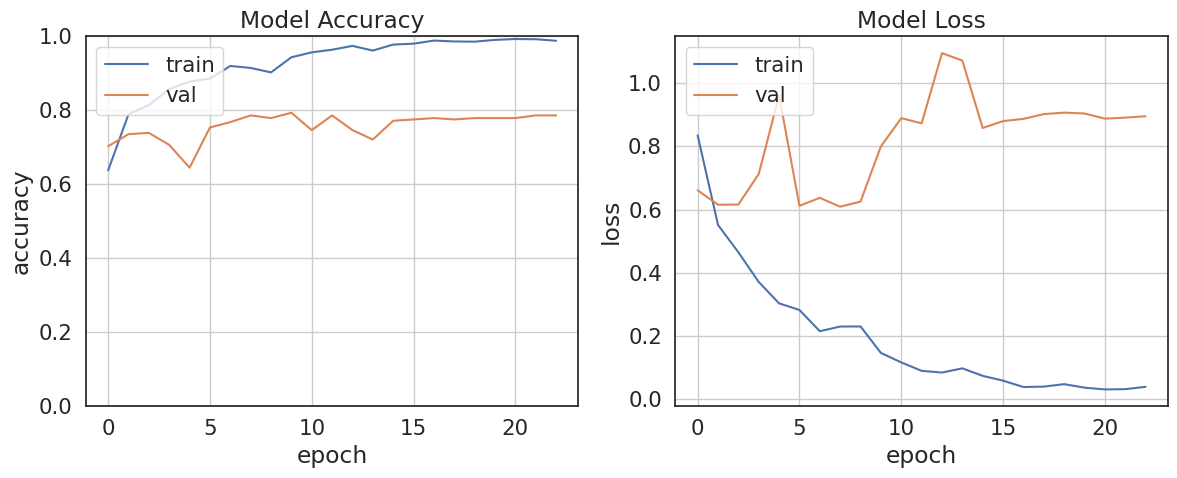


Calcolo metriche sul Validation Set...
F1-score (macro): 0.7846
Balanced Accuracy: 0.7892


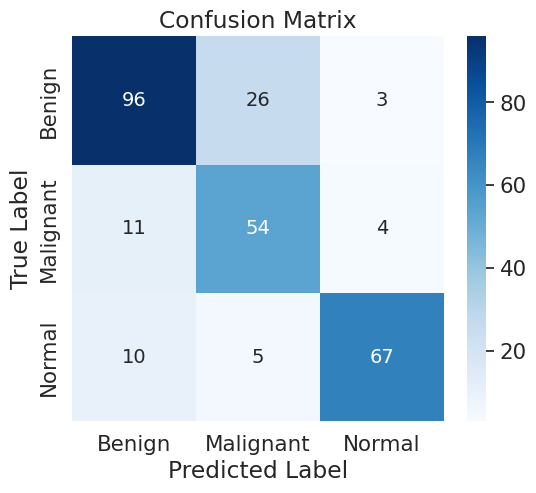

In [ ]:
# @title Plots
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# --- A. CARICAMENTO DEL MODELLO MIGLIORE ---
# Fondamentale: scartiamo i pesi dell'ultima epoca e ricarichiamo i migliori
model.load_state_dict(torch.load('best_model_vgg16.pth'))
model.eval() # Impostiamo in modalità valutazione
print(" Modello migliore caricato con successo.")

# --- B. PLOT ACCURACY & LOSS (Stile Prof) ---
plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.ylim([0, 1.0]) # Fissa asse Y tra 0 e 1

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- C. VALUTAZIONE SU VALIDATION SET (Matrice di Confusione) ---
print("\nCalcolo metriche sul Validation Set...")

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, _, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)

        # Otteniamo la classe vincente (argmax)
        # In PyTorch non serve la softmax per l'argmax, ma la mettiamo per coerenza
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Spostiamo su CPU e convertiamo in numpy
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Conversione in array numpy
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calcolo Metriche
f1 = f1_score(y_true, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"F1-score (macro): {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

# --- D. PLOT MATRICE DI CONFUSIONE ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
# Definisci i nomi delle classi nell'ordine corretto (es. 0, 1, 2)
# Controlla il tuo dataset per essere sicuro dell'ordine!
class_names = ['Benign', 'Malignant', 'Normal']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Il modello overfitta notevolmente: in realtà era prevedibile in quanto ci sono milioni di parametri su ~1600 immagini.

Comunque sul validation **Balanced Accuracy: 0.7892** non male


Provo a fine tunare aggiungendo adaptive pooling e riducendo la dimensione dei layer.

## Fine tuning

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

def build_vgg16_finetuning_final(num_classes=3):
    # Carica pesi ImageNet
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # 1. Input Grayscale (Indispensabile)
    original_first_layer = model.features[0]
    model.features[0] = nn.Conv2d(
        in_channels=1,
        out_channels=original_first_layer.out_channels,
        kernel_size=original_first_layer.kernel_size,
        stride=original_first_layer.stride,
        padding=original_first_layer.padding
    )
    with torch.no_grad():
        model.features[0].weight[:] = torch.mean(original_first_layer.weight, dim=1, keepdim=True)
        model.features[0].bias[:] = original_first_layer.bias

    # Replace the model's default avgpool with AdaptiveAvgPool2d((1, 1))
    # This will ensure the adaptive pooling is applied to the 4D output of 'features'
    # The model's forward method will then flatten it to (N, 512) before passing to classifier.
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # 2. CLASSIFICATORE "SMART" (Adaptive + Ridotto)
    # The input here will be (N, 512) because model.avgpool and torch.flatten
    # have already been applied by the VGG.forward method.
    model.classifier = nn.Sequential(
        nn.Linear(512, 512), # Original output channels of VGG's features
        nn.ReLU(True),
        nn.Dropout(p=0.5), # Dropout aggressivo (Standard VGG)

        nn.Linear(512, 128),
        nn.ReLU(True),
        nn.Dropout(p=0.4),

        nn.Linear(128, num_classes)
    )

    return model

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_fine = build_vgg16_finetuning_final(num_classes=3)
model_fine = model_fine.to(device)

In [ ]:
# --- CONFIGURAZIONE TRAINING ---

# 1. Congela TUTTO inizialmente
for param in model_fine.features.parameters():
    param.requires_grad = False

# 2. Scongela il PRIMO layer (Input Grayscale)
for param in model_fine.features[0].parameters():
    param.requires_grad = True

# 3. Scongela l'ULTIMO BLOCCO CONVOLUZIONALE (Block 5)
# VGG-16 ha i layer organizzati in features[0]...features[30]
# Il blocco 5 parte circa dal layer 24. Scongeliamo da lì in poi.
for layer in model_fine.features[24:]:
    for param in layer.parameters():
        param.requires_grad = True

# Verifica
trainable = sum(p.numel() for p in model_fine.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_fine.parameters())
print(f"Modalità Fine-Tuning: Addestrando {trainable} parametri su {total}.")

# 4. OTTIMIZZATORE DELICATO
# Usiamo un LR basso (1e-5) perché stiamo toccando i layer convoluzionali
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_fine.parameters()),
    lr=1e-5,           # <--- Fondamentale: lento e preciso
    weight_decay=1e-3  # <--- Weight Decay alto contro l'overfitting
)

criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-8)

# Importante: Reset Early Stopping se lo avevi usato prima
early_stopping = EarlyStopping(patience=12, path='best_model_vgg16_finetuned.pth')

Modalità Fine-Tuning: Addestrando 7408771 parametri su 15042243.


In [ ]:
# --- F. TRAIN THE MODEL ---
max_epochs = 200
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

print(f"Starting training for {max_epochs} epochs...")

for epoch in range(max_epochs):
    model_fine.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Training Loop
    for inputs, _, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_fine(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    # Validation Loop
    model_fine.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, _, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_fine(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total

    # Save History
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # Retrieve current Learning Rate (per sostituire verbose=True)
    current_lr = optimizer.param_groups[0]['lr']

    # PRINT STYLE
    print(f"Epoch {epoch+1}/{max_epochs}")
    print(f"{len(train_loader)}/{len(train_loader)} [==============================] - "
          f"loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - "
          f"val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.1e}")

    # Callbacks Steps
    old_lr = current_lr
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # Simuliamo il 'verbose' dello scheduler manualmente
    if new_lr != old_lr:
        print(f"  Epoch {epoch+1}: reducing learning rate to {new_lr:.1e}.")

    early_stopping(epoch_val_loss, model_fine)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best weights alla fine
model_fine.load_state_dict(torch.load('best_model_vgg16_finetuned.pth'))
print("Training finito. Modello migliore caricato.")

Starting training for 200 epochs...
Epoch 1/200
52/52 [==============================] - loss: 1.0981 - accuracy: 0.3357 - val_loss: 1.0865 - val_accuracy: 0.4529 - lr: 1.0e-05
Epoch 2/200
52/52 [==============================] - loss: 1.0963 - accuracy: 0.3412 - val_loss: 1.0807 - val_accuracy: 0.4529 - lr: 1.0e-05
Epoch 3/200
52/52 [==============================] - loss: 1.0877 - accuracy: 0.3899 - val_loss: 1.0671 - val_accuracy: 0.4746 - lr: 1.0e-05
Epoch 4/200
52/52 [==============================] - loss: 1.0619 - accuracy: 0.4765 - val_loss: 1.0071 - val_accuracy: 0.5870 - lr: 1.0e-05
Epoch 5/200
52/52 [==============================] - loss: 1.0066 - accuracy: 0.5463 - val_loss: 0.9177 - val_accuracy: 0.6304 - lr: 1.0e-05
Epoch 6/200
52/52 [==============================] - loss: 0.9255 - accuracy: 0.5969 - val_loss: 0.8376 - val_accuracy: 0.6268 - lr: 1.0e-05
Epoch 7/200
52/52 [==============================] - loss: 0.8733 - accuracy: 0.6131 - val_loss: 0.7934 - val_accuracy

 Modello migliore caricato con successo.


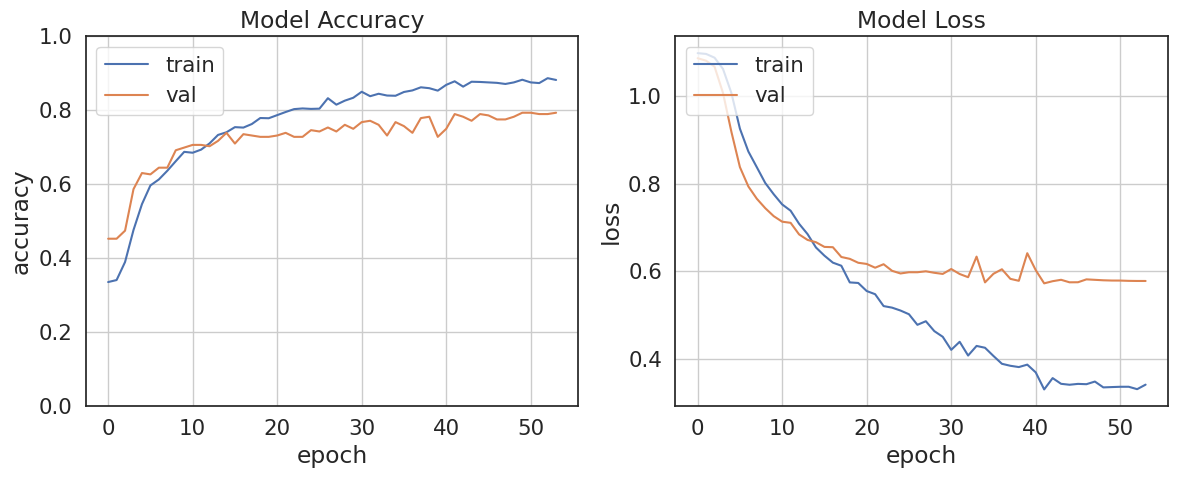


Calcolo metriche sul Validation Set...
F1-score (macro): 0.7782
Balanced Accuracy: 0.7752


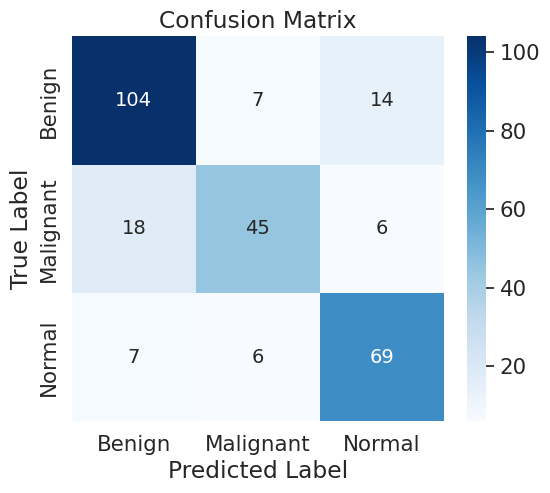

In [ ]:
# @title Plots
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# --- A. CARICAMENTO DEL MODELLO MIGLIORE ---
# Fondamentale: scartiamo i pesi dell'ultima epoca e ricarichiamo i migliori
model_fine.load_state_dict(torch.load('best_model_vgg16_finetuned.pth'))
model_fine.eval() # Impostiamo in modalità valutazione
print(" Modello migliore caricato con successo.")

# --- B. PLOT ACCURACY & LOSS (Stile Prof) ---
plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.ylim([0, 1.0]) # Fissa asse Y tra 0 e 1

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- C. VALUTAZIONE SU VALIDATION SET (Matrice di Confusione) ---
print("\nCalcolo metriche sul Validation Set...")

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, _, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_fine(inputs)

        # Otteniamo la classe vincente (argmax)
        # In PyTorch non serve la softmax per l'argmax, ma la mettiamo per coerenza
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Spostiamo su CPU e convertiamo in numpy
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Conversione in array numpy
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calcolo Metriche
f1 = f1_score(y_true, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"F1-score (macro): {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

# --- D. PLOT MATRICE DI CONFUSIONE ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
# Definisci i nomi delle classi nell'ordine corretto (es. 0, 1, 2)
# Controlla il tuo dataset per essere sicuro dell'ordine!
class_names = ['Benign', 'Malignant', 'Normal']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

MOLTO meglio, overfitta più tardi. Fa comunque fatica su classe minoritaria (maligna) nonostante l'augmentation.


## Finetuning 2.0

Fino ad ora abbiamo modificato il primo livello della VGG (model.features[0]) per accettare 1 canale, facendo la media dei pesi. Il problema: Facendo la media dei pesi, "rompiamo" parzialmente i filtri che la VGG ha imparato su ImageNet. Quei filtri erano perfetti per cercare bordi e texture in RGB. La Soluzione: Non tocchiamo l'architettura della VGG. Lasciamola a 3 canali. Invece, nel Dataset, prendiamo la tua immagine in bianco e nero e la ripetiamo 3 volte.

- Vantaggio: Sfrutti al 100% la potenza pre-addestrata della VGG senza "annacquare" i pesi iniziali.

In [ ]:
class BreastUSDataset2(Dataset):
    def __init__(self, images, masks, labels, transform=None):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        mask = self.masks[idx]
        label = self.labels[idx]

        # Assicuriamoci uint8
        if img.dtype != 'uint8':
            if img.max() <= 1.5: img = (img * 255).astype('uint8')
            else: img = img.astype('uint8')

        # Augmentation
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Normalizzazione float32
        img = img.astype('float32') / 255.0

        # --- MODIFICA CHIAVE: 1 Canale -> 3 Canali ---
        # Se è (H, W), diventa (H, W, 1)
        if img.ndim == 2:
            img = img[:, :, None]

        # Da Numpy (H, W, C) a Tensor (C, H, W)
        img = torch.from_numpy(img).permute(2, 0, 1) # Ora è (1, 256, 256)

        # RIPETI IL CANALE 3 VOLTE: Diventa (3, 256, 256)
        # Questo imbroglia la VGG facendole credere sia RGB (è la stessa cosa di convertire in RGB in questo caso)
        img = img.repeat(3, 1, 1)

        # Maschere e Label
        mask = (mask > 0.5).astype('float32')
        if mask.ndim == 2: mask = mask[:, :, None]
        mask = torch.from_numpy(mask).permute(2, 0, 1)
        label = torch.tensor(label, dtype=torch.long)

        return img, mask, label

In [ ]:
# --- CONFIGURAZIONE BATCH SIZE ---
BATCH_SIZE = 32

# 1. Dataset di Training (Usa i dati BILANCIATI + Transform ONLINE)
train_dataset2 = BreastUSDataset2(
    X_train_bal,
    masks_train_bal,
    y_train_bal,
    transform=train_transform
)

# 2. Dataset di Validation (Usa i dati ORIGINALI + Transform VUOTA)
# Il Validation NON deve essere bilanciato artificialmente, deve riflettere la realtà.
val_dataset2 = BreastUSDataset2(
    X_val,
    masks_val,
    y_val,
    transform=val_transform
)

# 3. Creazione DataLoader
train_loader2 = DataLoader(
    train_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=True,       # IMPORTANTE: Mescolare i dati di training
    num_workers=2,      # Velocizza il caricamento (usa 0 se dà errori su Windows)
    pin_memory=True     # Velocizza trasferimento su GPU
)

val_loader2 = DataLoader(
    val_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=False,      # Non serve mescolare il validation
    num_workers=2,
    pin_memory=True
)

print(f"   DataLoaders pronti.")
print(f"   Batch Train: {len(train_loader2)} (Totale img: {len(train_dataset2)})")
print(f"   Batch Val:   {len(val_loader2)} (Totale img: {len(val_dataset2)})")

   DataLoaders pronti.
   Batch Train: 52 (Totale img: 1662)
   Batch Val:   9 (Totale img: 276)


In [ ]:
def build_vgg16_3channel_model(num_classes=3):
    # Carica VGG16 standard (aspetta 3 canali in input)
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # NON MODIFICHIAMO model.features[0]!
    # Lo lasciamo com'è (3 canali in input)

    # Replace the model's default avgpool with AdaptiveAvgPool2d((1, 1))
    # This will ensure the adaptive pooling is applied to the 4D output of 'features'
    # The model's forward method will then flatten it to (N, 512) before passing to classifier.
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # Modifichiamo solo il Classificatore (Head)
    # The input here will be (N, 512) because model.avgpool and torch.flatten
    # have already been applied by the VGG.forward method.
    model.classifier = nn.Sequential(
        nn.Linear(512, 512),
        nn.ReLU(True),
        nn.Dropout(p=0.3), # Dropout ridotto a 0.3 per imparare di più

        nn.Linear(512, 128),
        nn.ReLU(True),
        nn.Dropout(p=0.3),

        nn.Linear(128, num_classes)
    )
    return model

In [ ]:
# --- 2. SETUP E RESET ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Creiamo il modello nuovo
model2 = build_vgg16_3channel_model(num_classes=3)
model2 = model2.to(device)

# --- 3. CONFIGURAZIONE FREEZING (Strategia Mista) ---
# Congeliamo tutto all'inizio
for param in model2.features.parameters():
    param.requires_grad = False

# Scongeliamo l'ultimo blocco convoluzionale (Block 5) per adattarsi all'ecografia
for layer in model2.features[24:]:
    for param in layer.parameters():
        param.requires_grad = True

# Assicuriamoci che il classificatore sia sbloccato
for param in model2.classifier.parameters():
    param.requires_grad = True

# --- 4. OTTIMIZZATORE E LOSS (FIXED) ---
# Class Weights: Puniamo doppio l'errore sui Maligni (Classe 1)
# Assumiamo ordine: 0=Benign, 1=Malignant, 2=Normal
class_weights = torch.tensor([1.0, 2.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# IMPORTANTE: Qui passiamo model2.parameters() -> Questo risolve il bug del 33% stuck
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr=5e-5,           # LR basso e sicuro per fine-tuning
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-8)
early_stopping = EarlyStopping(patience=15, path='best_model2_final_3ch.pth')

In [ ]:
# --- 5. TRAINING LOOP ---
max_epochs = 200 # Imposta quante ne vuoi, tanto c'è early stopping

print(f"Avvio Training Finale su model2 ({max_epochs} epochs)...")

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(max_epochs):
    # -- Training Phase --
    model2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, _, labels in train_loader2: # Usa il loader a 3 canali
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader2.dataset)
    epoch_acc = correct / total

    # -- Validation Phase --
    model2.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, _, labels in val_loader2:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model2(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader2.dataset)
    epoch_val_acc = val_correct / val_total

    # -- Salvataggio e Print --
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{max_epochs} | "
          f"Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f} | lr: {current_lr:.1e}")

    # -- Callbacks --
    scheduler.step(epoch_val_loss)
    early_stopping(epoch_val_loss, model2)

    if early_stopping.early_stop:
        print("Early stopping triggered. Training terminato.")
        break

# Carica il peso migliore alla fine
model2.load_state_dict(torch.load('best_model2_final_3ch.pth'))
print("Modello finale caricato e pronto.")

Avvio Training Finale su model2 (200 epochs)...
Epoch 1/200 | Loss: 1.0338 - Acc: 0.3339 | Val Loss: 1.0450 - Val Acc: 0.2572 | lr: 5.0e-05
Epoch 2/200 | Loss: 0.8644 - Acc: 0.5174 | Val Loss: 0.8858 - Val Acc: 0.5761 | lr: 5.0e-05
Epoch 3/200 | Loss: 0.7326 - Acc: 0.6438 | Val Loss: 0.7448 - Val Acc: 0.6812 | lr: 5.0e-05
Epoch 4/200 | Loss: 0.6416 - Acc: 0.7088 | Val Loss: 0.7181 - Val Acc: 0.7065 | lr: 5.0e-05
Epoch 5/200 | Loss: 0.5730 - Acc: 0.7473 | Val Loss: 0.6832 - Val Acc: 0.7101 | lr: 5.0e-05
Epoch 6/200 | Loss: 0.5200 - Acc: 0.7659 | Val Loss: 0.6526 - Val Acc: 0.7065 | lr: 5.0e-05
Epoch 7/200 | Loss: 0.4807 - Acc: 0.7948 | Val Loss: 0.6262 - Val Acc: 0.7464 | lr: 5.0e-05
Epoch 8/200 | Loss: 0.4353 - Acc: 0.8117 | Val Loss: 0.6119 - Val Acc: 0.7536 | lr: 5.0e-05
Epoch 9/200 | Loss: 0.3758 - Acc: 0.8490 | Val Loss: 0.6331 - Val Acc: 0.7681 | lr: 5.0e-05
Epoch 10/200 | Loss: 0.3687 - Acc: 0.8436 | Val Loss: 0.5858 - Val Acc: 0.7681 | lr: 5.0e-05
Epoch 11/200 | Loss: 0.3528 - A

 Modello migliore caricato con successo.


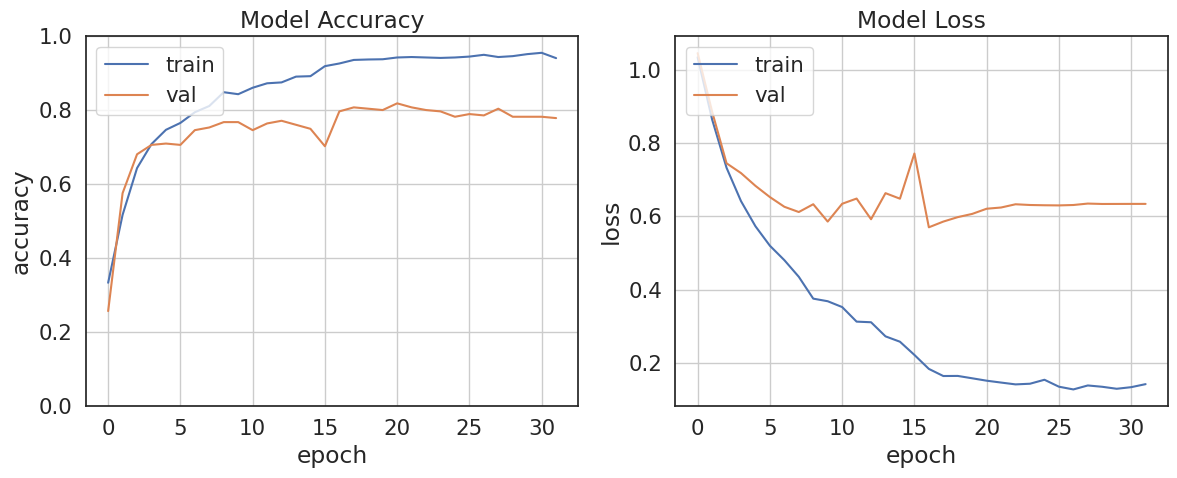


Calcolo metriche sul Validation Set...
F1-score (macro): 0.7911
Balanced Accuracy: 0.7943


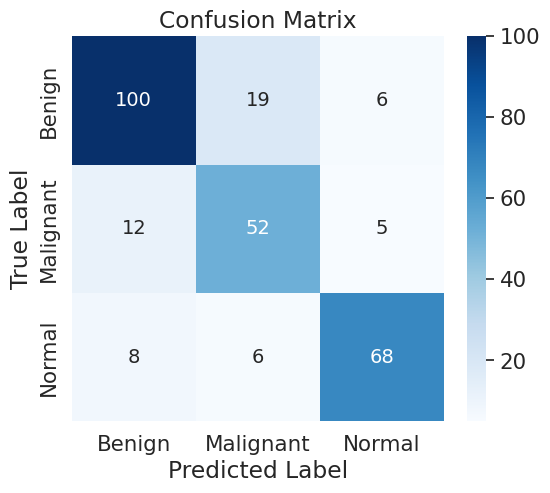

In [ ]:
# @title Plots
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# --- A. CARICAMENTO DEL MODELLO MIGLIORE ---
# Fondamentale: scartiamo i pesi dell'ultima epoca e ricarichiamo i migliori
model2.load_state_dict(torch.load('best_model2_final_3ch.pth'))
model2.eval() # Impostiamo in modalità valutazione
print(" Modello migliore caricato con successo.")

# --- B. PLOT ACCURACY & LOSS (Stile Prof) ---
plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.ylim([0, 1.0]) # Fissa asse Y tra 0 e 1

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- C. VALUTAZIONE SU VALIDATION SET (Matrice di Confusione) ---
print("\nCalcolo metriche sul Validation Set...")

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, _, labels in val_loader2:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model2(inputs)

        # Otteniamo la classe vincente (argmax)
        # In PyTorch non serve la softmax per l'argmax, ma la mettiamo per coerenza
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Spostiamo su CPU e convertiamo in numpy
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Conversione in array numpy
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calcolo Metriche
f1 = f1_score(y_true, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"F1-score (macro): {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

# --- D. PLOT MATRICE DI CONFUSIONE ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
# Definisci i nomi delle classi nell'ordine corretto (es. 0, 1, 2)
# Controlla il tuo dataset per essere sicuro dell'ordine!
class_names = ['Benign', 'Malignant', 'Normal']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Guarda la classe centrale (Malignant):

- Corretti: 52 (su 69 totali).
- Errori: Solo 12 confusi come Benigni e 5 come Normali.

La Loss di Validation tocca il minimo intorno all'Epoca 8-10 (a circa 0.60) e poi inizia a risalire lentamente, mentre la Training Loss continua a scendere a picco --> Sì, è Overfitting. Ma è un overfitting "diverso" da prima.
- Input a 3 Canali: Hai dato alla VGG i dati nel formato che lei "ama". Invece di dover imparare da zero a leggere un canale solo, ha potuto usare subito i suoi filtri potenti. Ha imparato molto più in fretta!

- Learning Rate 5e-5: È un po' più alto del 1e-5 super-cauto. Ha accelerato la convergenza.

Posso provare rimettendo drop out a 0.5

## Finetuning 3.0

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

# --- 1. MODELLO CON DROPOUT AUMENTATO (0.5) ---
def build_vgg16_high_reg(num_classes=3):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    # Replace the model's default avgpool with AdaptiveAvgPool2d((1, 1))
    # This will ensure the adaptive pooling is applied to the 4D output of 'features'
    # The model's forward method will then flatten it to (N, 512) before passing to classifier.
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    # Classificatore con Dropout 0.5 (Standard VGG)
    model.classifier = nn.Sequential(
        nn.Linear(512, 512),
        nn.ReLU(True),
        nn.Dropout(p=0.5), # <--- AUMENTATO a 0.5
        nn.Linear(512, 128),
        nn.ReLU(True),
        nn.Dropout(p=0.5), # <--- AUMENTATO a 0.5
        nn.Linear(128, num_classes)
    )
    return model

# --- 2. SETUP (Reset Totale) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3 = build_vgg16_high_reg(num_classes=3) # Usiamo model3 per non confonderci
model3 = model3.to(device)

# Configurazione Freezing (Mista)
for param in model3.features.parameters():
    param.requires_grad = False
for layer in model3.features[24:]: # Scongela ultimo blocco
    for param in layer.parameters():
        param.requires_grad = True
for param in model3.classifier.parameters():
    param.requires_grad = True

# --- 3. OTTIMIZZATORE CON WEIGHT DECAY AGGRESSIVO ---
class_weights = torch.tensor([1.0, 2.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model3.parameters()),
    lr=5e-5,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-9)
early_stopping = EarlyStopping(patience=20, path='best_model3_reg.pth') # Pazienza aumentata a 20

In [ ]:
# --- 4. TRAINING LOOP ---
max_epochs = 200
print(f"Avvio Training 'High Regularization' (Dropout 0.5, WD 0.01)...")

history_reg = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(max_epochs):
    model3.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, _, labels in train_loader2:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model3(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader2.dataset)
    epoch_acc = correct / total

    model3.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, _, labels in val_loader2:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model3(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader2.dataset)
    epoch_val_acc = val_correct / val_total

    history_reg['loss'].append(epoch_loss)
    history_reg['accuracy'].append(epoch_acc)
    history_reg['val_loss'].append(epoch_val_loss)
    history_reg['val_accuracy'].append(epoch_val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{max_epochs} | Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f} | lr: {current_lr:.1e}")

    scheduler.step(epoch_val_loss)
    early_stopping(epoch_val_loss, model3)

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

model3.load_state_dict(torch.load('best_model3_reg.pth'))
print("Modello High-Reg caricato.")

Avvio Training 'High Regularization' (Dropout 0.5, WD 0.01)...
Epoch 1/200 | Loss: 1.0495 - Acc: 0.3436 | Val Loss: 1.0703 - Val Acc: 0.2500 | lr: 5.0e-05
Epoch 2/200 | Loss: 0.9210 - Acc: 0.4609 | Val Loss: 0.9162 - Val Acc: 0.5580 | lr: 5.0e-05
Epoch 3/200 | Loss: 0.8161 - Acc: 0.5890 | Val Loss: 0.8100 - Val Acc: 0.6739 | lr: 5.0e-05
Epoch 4/200 | Loss: 0.7368 - Acc: 0.6390 | Val Loss: 0.7396 - Val Acc: 0.6703 | lr: 5.0e-05
Epoch 5/200 | Loss: 0.6746 - Acc: 0.6847 | Val Loss: 0.6936 - Val Acc: 0.6993 | lr: 5.0e-05
Epoch 6/200 | Loss: 0.6398 - Acc: 0.7112 | Val Loss: 0.7993 - Val Acc: 0.5978 | lr: 5.0e-05
Epoch 7/200 | Loss: 0.5614 - Acc: 0.7617 | Val Loss: 0.6455 - Val Acc: 0.7464 | lr: 5.0e-05
Epoch 8/200 | Loss: 0.5240 - Acc: 0.7774 | Val Loss: 0.6414 - Val Acc: 0.7355 | lr: 5.0e-05
Epoch 9/200 | Loss: 0.4632 - Acc: 0.8087 | Val Loss: 0.6197 - Val Acc: 0.7536 | lr: 5.0e-05
Epoch 10/200 | Loss: 0.4397 - Acc: 0.8225 | Val Loss: 0.6802 - Val Acc: 0.6957 | lr: 5.0e-05
Epoch 11/200 | L

 Modello migliore caricato con successo.


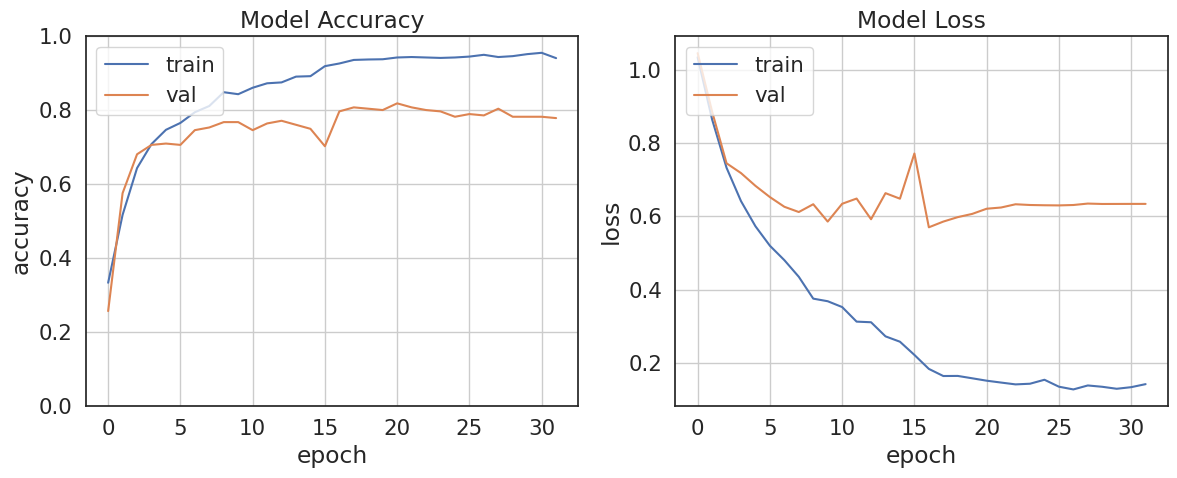


Calcolo metriche sul Validation Set...
F1-score (macro): 0.8036
Balanced Accuracy: 0.8088


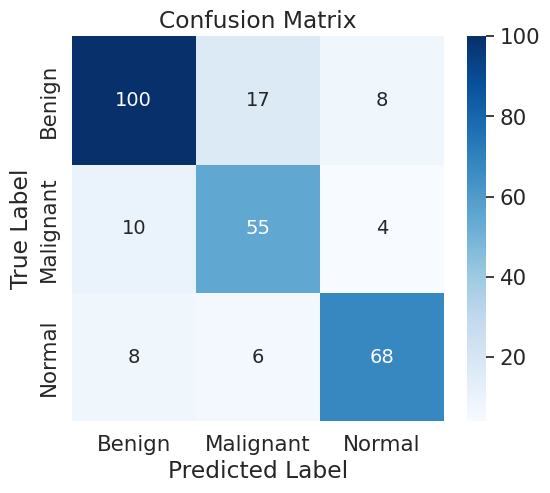

In [ ]:
# @title Plots
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score

# --- A. CARICAMENTO DEL MODELLO MIGLIORE ---
# Fondamentale: scartiamo i pesi dell'ultima epoca e ricarichiamo i migliori
model3.load_state_dict(torch.load('best_model3_reg.pth'))
model3.eval() # Impostiamo in modalità valutazione
print(" Modello migliore caricato con successo.")

# --- B. PLOT ACCURACY & LOSS (Stile Prof) ---
plt.figure(figsize=(12, 5))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.ylim([0, 1.0]) # Fissa asse Y tra 0 e 1

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- C. VALUTAZIONE SU VALIDATION SET (Matrice di Confusione) ---
print("\nCalcolo metriche sul Validation Set...")

y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, _, labels in val_loader2:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model3(inputs)

        # Otteniamo la classe vincente (argmax)
        # In PyTorch non serve la softmax per l'argmax, ma la mettiamo per coerenza
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Spostiamo su CPU e convertiamo in numpy
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Conversione in array numpy
y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

# Calcolo Metriche
f1 = f1_score(y_true, y_pred, average='macro')
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"F1-score (macro): {f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

# --- D. PLOT MATRICE DI CONFUSIONE ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
# Definisci i nomi delle classi nell'ordine corretto (es. 0, 1, 2)
# Controlla il tuo dataset per essere sicuro dell'ordine!
class_names = ['Benign', 'Malignant', 'Normal']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()